Loaded delta-100-0.txt: angle=0.0°, Fx=3.770e+01, Fy=0.000e+00, components=x, n_points=30
maximum displacement (x): 11.52
sigma_noise added (x): 0.2303 (2.0% of maximum displacement)
realized experimental noise (x): 0.216
sigma_noise prior: Exp(beta=0.8533)
Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\data_vs_noise.pdf


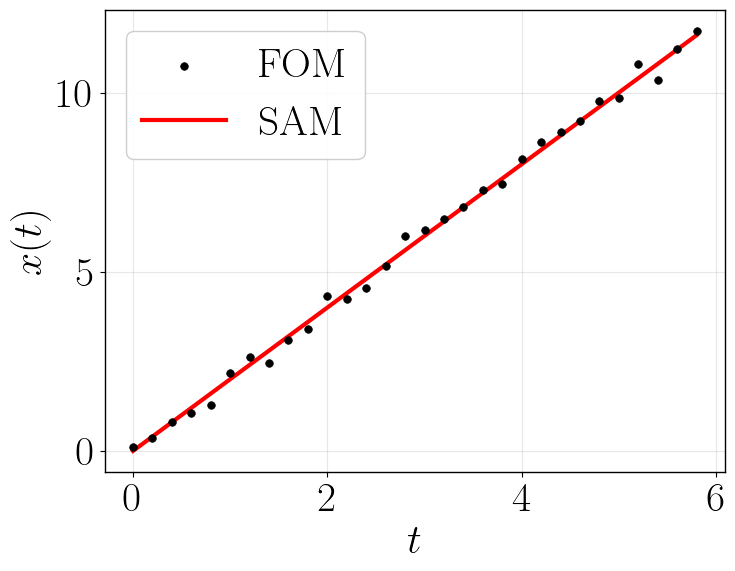

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\prior.pdf


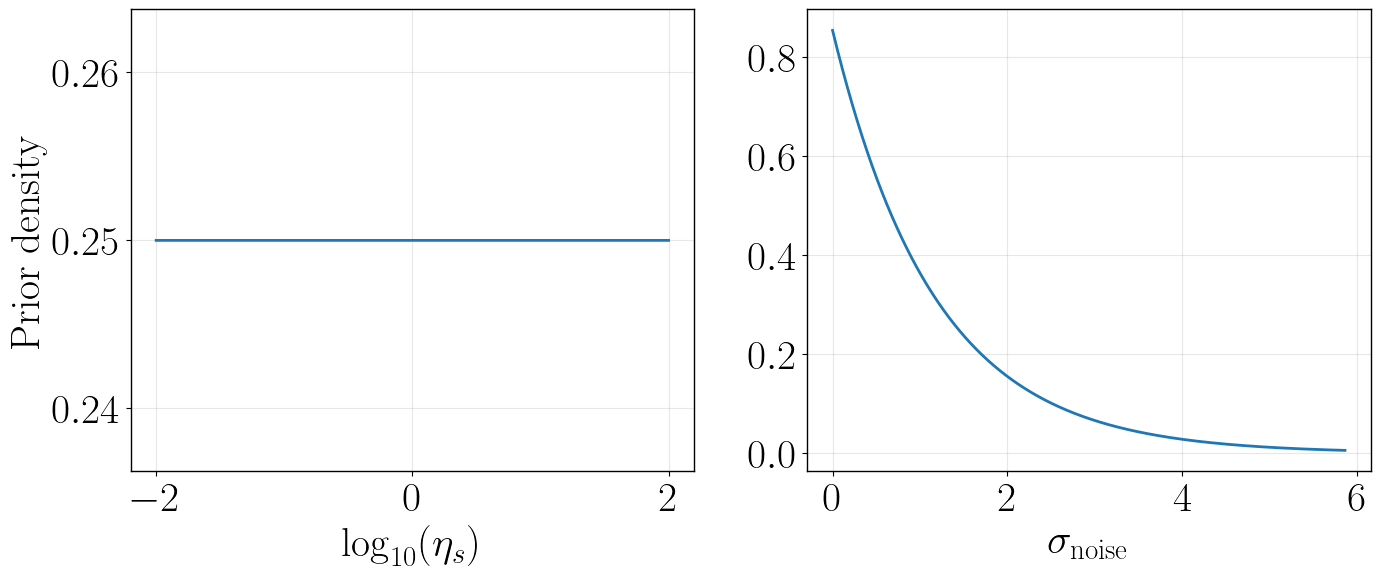


Preparing MCMC: ndim=2, walkers=4, steps=10000, init=kmeans, warmup=True

Initial walkers (physical):
  00: [0.11869426 2.18079431]
  01: [11.21832242  0.7954441 ]
  02: [0.11440597 0.46908361]
  03: [2.95577309 4.31863761]

Warm-up: 1000 steps x 4 walkers


Warm-up:   0%|          | 0/1000 [00:00<?, ?it/s]


Walkers after warm-up (physical):
  00: [0.99872332 0.22540451]
  01: [0.99005415 0.17737728]
  02: [0.97521062 0.23575282]
  03: [0.9964791 0.211975 ]


MCMC:   0%|          | 0/10000 [00:00<?, ?it/s]


MCMC Diagnostics Summary
Chains: 4  |  Samples/chain after burn-in: 7000  |  Total: 28000
----------------------------------------------------------------
Parameter                Mean            Std       Rhat
----------------------------------------------------------------
eta_s              9.9597e-01     6.0042e-03     1.0032
sigma_noise        2.1892e-01     2.9884e-02     1.0024
----------------------------------------------------------------
Mean Rhat                                        1.0028
Std Rhat                                         0.0004

All parameters show good convergence (Rhat <= 1.1)


Posterior-predictive adequacy (x, replicated data):
  Nominal central coverage of band:  95.0%
  ----------------------------------------------------------------
  series               cover     RMS z    max|z|    mean z
  dataset[0] x         96.7%      0.92      2.19     -0.05
Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\posterior_predictive.pdf


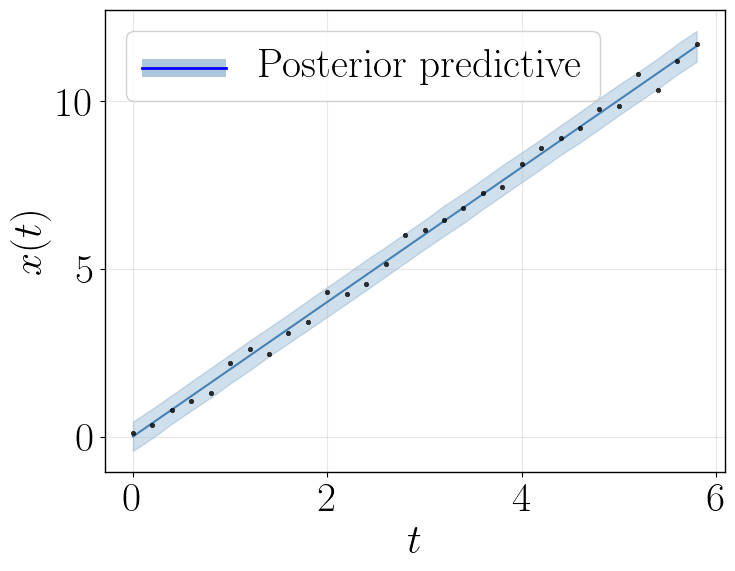

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\corner.pdf


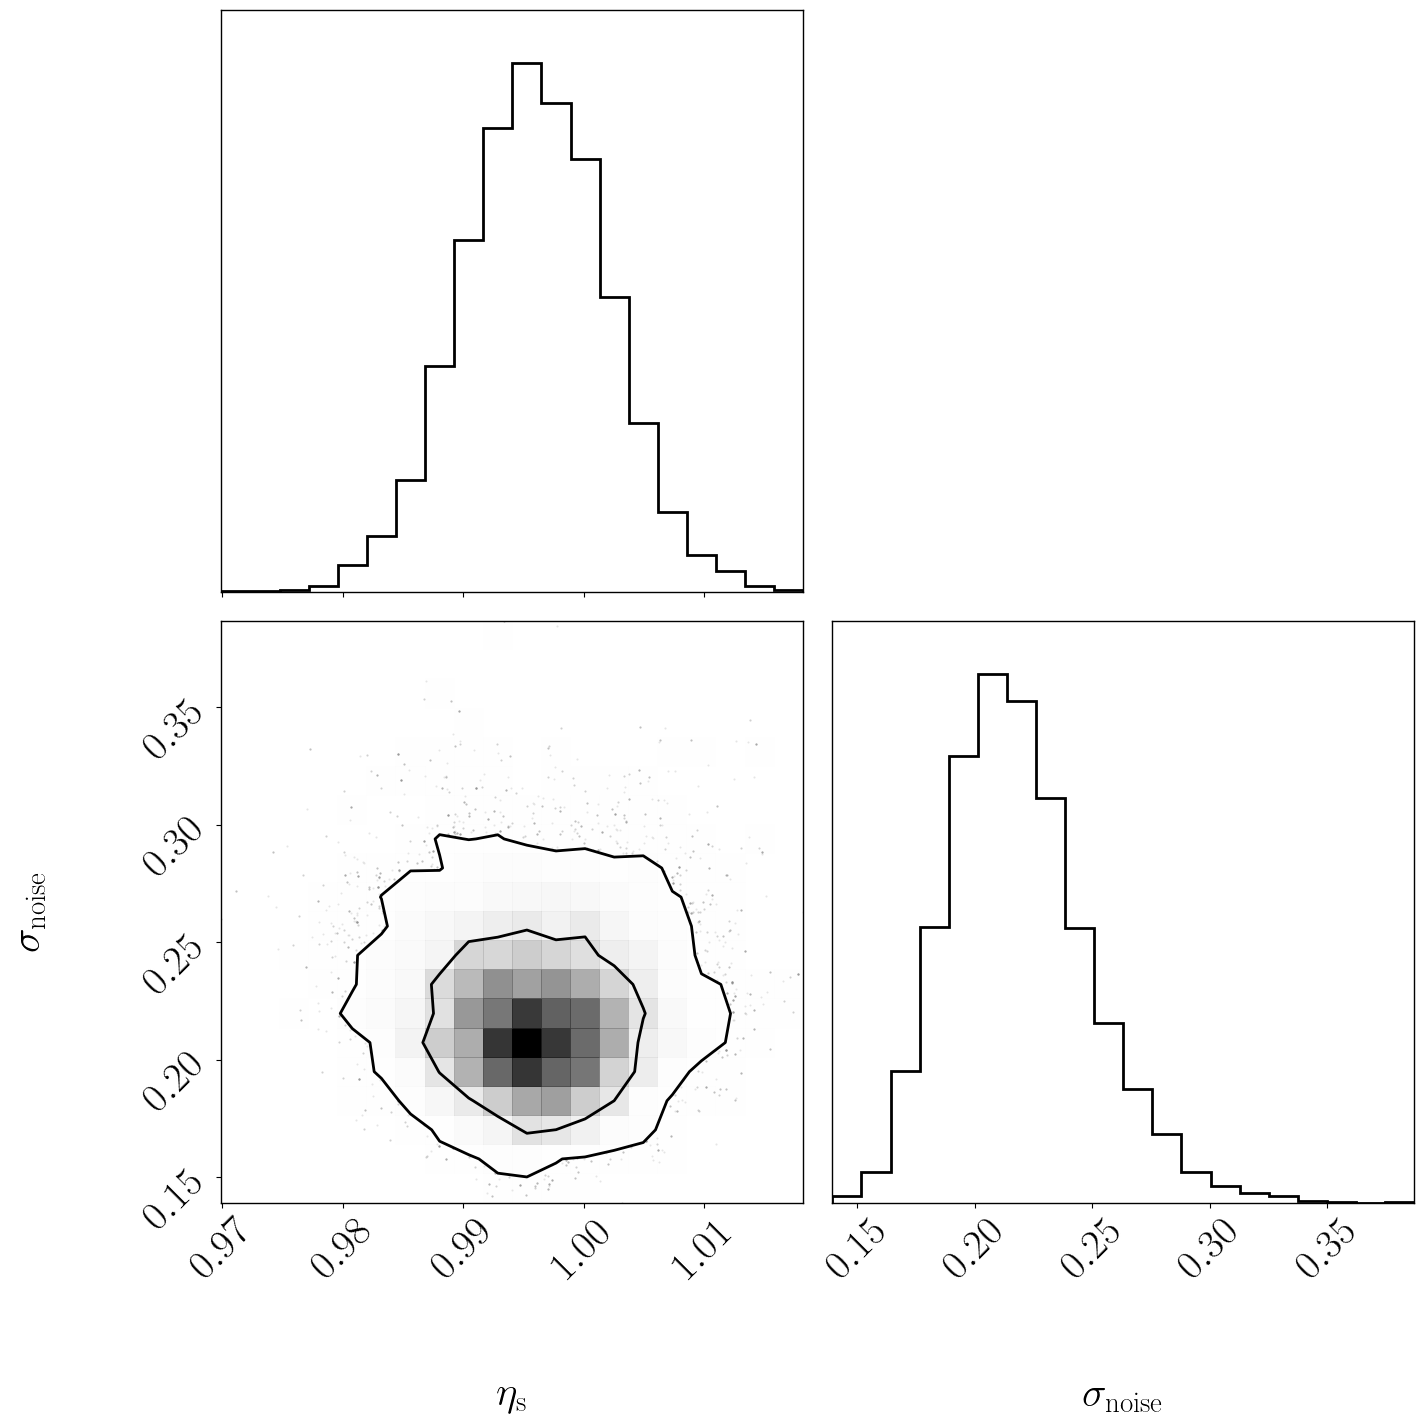

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\trace.pdf


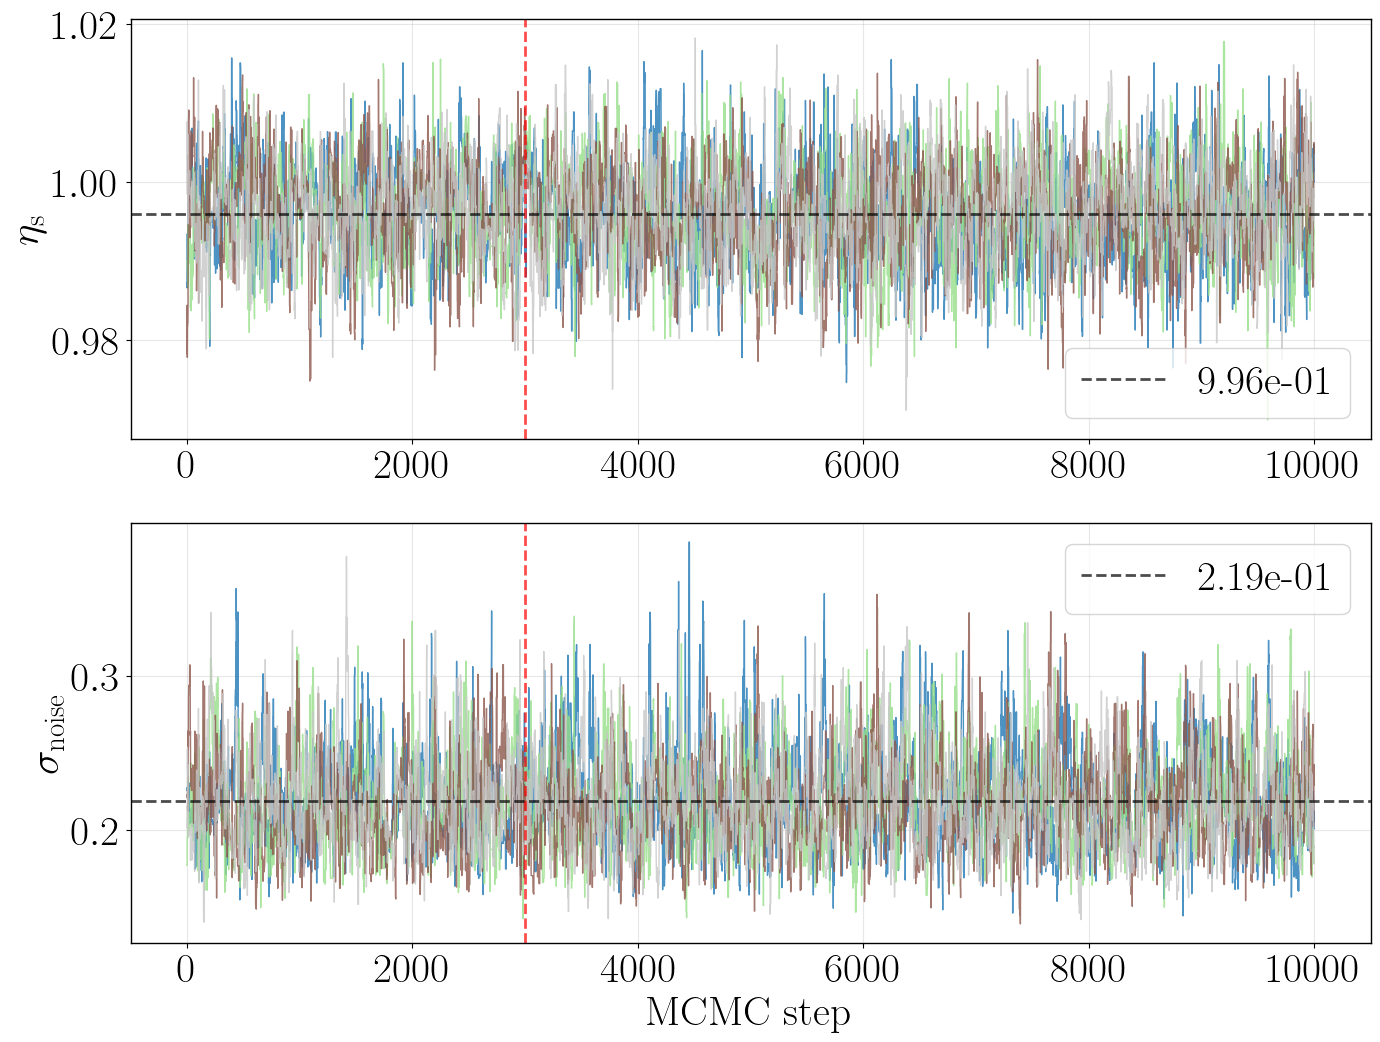

In [2]:
import sys
import os
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from packages.main import  InferenceProcedure

model = InferenceProcedure(
    force=12*np.pi,
    material_model="newtonian", # "newtonian", "viscoelastic"
    boundary_model="unbounded", # "unbounded", "bounded"
    theta=0, 
    a=1.0,
    sigma_noise_percent= 2.0,
    sigma_bias=None,
    nsteps=10000,
    thin_factor=1)

model.load_data("data/newtonian/unbounded/delta-100-0.txt")
model.plot_data(theta_true=[1])
model.plot_prior()
model.run_mcmc(init_method= "kmeans")
model.plot_results()